# ENVIROMENT SETUP

Permission Flag for Sampling Tables

In [1]:
permToSampleTables = False
using_open_ai=False

In [2]:
%pip install datasets
%pip install --upgrade protobuf
!pip install transformers sentence_transformers torch-scatter
!pip install wandb setuptools
!pip install kneed scikit-learn
!pip install matplotlib
!pip install "langchain" "langchain-text-splitters" "langchain-pinecone" "pinecone[grpc]" "pinecone-client" "langchain-ollama" "langchain-community" "langchain-openai"
!pip install --upgrade langchain-core    


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: /Users/fdhanani/Documents/thesis/venv_thesis/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: /Users/fdhanani/Documents/thesis/venv_thesis/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.3.1 -> 24.3.1
[notice] To update, run: python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 24.3.1
[notice] To update, run: python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 24.3.1
[notice] To update, run: python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 24.3.1
[notice] To update, run: python3.11 -m pip install --upgrade pip

[notice] A new rele

In [3]:
%pip install transformers torch torchvision torchaudio


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: /Users/fdhanani/Documents/thesis/venv_thesis/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Required Imports

In [4]:
import os
import json
import time
import numpy as np

# data sets
import pandas as pd
from tqdm.auto import tqdm
from datasets import load_dataset

# LangChain Core
from langchain_core.embeddings import Embeddings

# LangChain
from langchain_ollama import OllamaEmbeddings

# LangChain
from langchain_openai import OpenAIEmbeddings


# Document
from langchain.docstore.document import Document

# PineCone
from pinecone import Pinecone, ServerlessSpec
#from pinecone.grpc import PineconeGRPC as Pinecone
from langchain_pinecone import PineconeEmbeddings
from langchain_pinecone import PineconeVectorStore

# silhoutee & Kmeans
from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# WandDB
import wandb

import torch
from transformers import BertModel, AutoTokenizer

/Users/fdhanani/Documents/thesis/venv_thesis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import getpass
import os

file_path = './keys/openai_keys.txt'
with open(file_path, 'r', encoding='utf-8') as file:
    open_ai_key = file.read()

if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = open_ai_key

file_path = './keys/pinecone_keys.txt'
with open(file_path, 'r', encoding='utf-8') as file:
    pinecone_key = file.read()

if not os.getenv("PINECONE_API_KEY"):
    os.environ["PINECONE_API_KEY"] = pinecone_key

In [6]:
base_path = "./"

# Loading Dataset

In [7]:
dataset = load_dataset("DongfuTingle/FeTaQA")

# PROCESSING DATA-SETS

## Sampling Records from the Loaded Data-Sets

In [8]:
def keep_ascii_printable(original_namespace: str) -> str:
    # Keep only ASCII-printable characters (code range 32 to 126)
    sanitized_namespace = original_namespace.replace(" ", "_").replace("(", "").replace(")", "").replace("–", "-")
    return ''.join(char for char in sanitized_namespace if 32 <= ord(char) <= 126)

In [9]:
def sampleTables(datasetFileName, totalRecordsToSample):
  processedDataSet=[]
  for index in range(totalRecordsToSample):

    '''
      # Loading data-frame
    '''
    headers = dataset['train'][index]['table_array'][0]
    content = dataset['train'][index]['table_array'][1:]
    table = pd.DataFrame(content, columns=headers)

    '''
      # Renaming duplicate column names
    '''
    s = pd.Series(table.columns)
    table.columns = table.columns+((" "+s.groupby(s).cumcount().astype(str)).replace(' 0','').astype(str))

    '''
      # Creating rows & cols chunks
    '''
    rowChunks = table.to_dict('records')
    colChunks = table.to_dict('list')
    allChunks = []

    for row in rowChunks:
      allChunks.append(row)

    for col in colChunks:
      colChunk = colChunks[col]
      allChunks.append({col:colChunk})

    allChunks.append({'table_page_title' :dataset['train'][index]['table_page_title']})
    allChunks.append({'table_section_title' :dataset['train'][index]['table_section_title']})
      
    namespace = keep_ascii_printable(
        dataset['train'][index]['table_page_title']  + 
        " " + 
        dataset['train'][index]['table_section_title']
    )

    wholeChunk = {
        namespace:allChunks
    }
      
    processedDataSet.append(wholeChunk)

  '''
    # Saving extracted rows & cols chunks
  '''
  with open(base_path+datasetFileName, "w", encoding='utf8') as outfile:
      outfile.write(json.dumps(processedDataSet, indent = 4, ensure_ascii=False))

  return

## Pre-Processing Sampled Records

In [9]:
def _preprocess_tables(datasetFileName):
  with open(base_path+datasetFileName, 'r', encoding='utf8') as infile:
    processedDataSet = json.load(infile)

  name_space_chunks = {}
  for wholeChunk in processedDataSet:
    for mainKey in wholeChunk:
        chunks = wholeChunk[mainKey]
        documents=[]
        for chunk in chunks:
            documents.append(Document(page_content=json.dumps(chunk, indent = 4, ensure_ascii=False)))
        name_space_chunks[mainKey] = documents
  return name_space_chunks

## Saving Pre-Proccessed Sampled Records

In [11]:
datasetFileName = "dataset/TQA.json"
totalRecordsToSample = 10

In [11]:
if(permToSampleTables):
  sampleTables(datasetFileName, totalRecordsToSample)

# Setup Vector-Store Pinecone

In [12]:
pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])

index_name = "rag-test-open-ai" if using_open_ai  else "rag_test_ollama"
vc_dimension=3072 if using_open_ai else 1024

if not pc.has_index(index_name):
  pc.create_index(
        name=index_name,
        dimension=vc_dimension,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )
  
  while not pc.describe_index(index_name).status["ready"]:
        time.sleep(1)

pinecone_index = pc.Index(index_name)

# Generating Embeddings

In [13]:
# Embedding Model
'''
model_name = "mxbai-embed-large"
embeddings = OllamaEmbeddings(
    model=model_name,
    base_url="http://localhost:11434",
)
'''

open_ai_model_name = "text-embedding-3-large"
embeddings = OpenAIEmbeddings(
    model=open_ai_model_name,
)

In [14]:
# verificaion that embeddings is working properly
em = embeddings.embed_documents(['hello'])

In [15]:
em

[[-0.024605071172118187,
  -0.0075481850653886795,
  0.004001544788479805,
  0.006006342824548483,
  0.005100560374557972,
  0.00025600928347557783,
  -0.006396835204213858,
  0.05249511078000069,
  0.009637522511184216,
  0.05655301734805107,
  -0.004404114559292793,
  -0.021223483607172966,
  -0.021626053377985954,
  -0.010378251783549786,
  -0.017841897904872894,
  0.020176801830530167,
  0.024073679000139236,
  0.005958034191280603,
  0.015080267563462257,
  -0.011932170949876308,
  0.01062784530222416,
  -0.008123859763145447,
  0.0011161250295117497,
  0.03507188707590103,
  0.010040093213319778,
  0.031239422038197517,
  -0.02083701640367508,
  -0.01726219616830349,
  -0.04933896288275719,
  -0.033751457929611206,
  0.0008765959064476192,
  0.0263119675219059,
  0.0019091876456514,
  0.019097914919257164,
  0.03555497154593468,
  0.007141589652746916,
  0.026585714891552925,
  0.004404114559292793,
  -0.023864341899752617,
  0.02241509035229683,
  0.02673063986003399,
  0.008719

In [16]:
pinecone_index.describe_index_stats()

{'dimension': 3072,
 'index_fullness': 0.0,
 'namespaces': {},
 'total_vector_count': 0}

In [17]:
existing_namespaces = pinecone_index.describe_index_stats()['namespaces']

In [18]:
existing_namespaces

{}

In [19]:
processed_tables = _preprocess_tables(datasetFileName)

In [20]:
vector_store = PineconeVectorStore(
    index = pinecone_index,
    embedding=embeddings,
    pinecone_api_key=os.environ["PINECONE_API_KEY"]
)

In [21]:
for namespace in tqdm(processed_tables):
    try:
        if namespace not in existing_namespaces:
            documents = processed_tables[namespace]
            vector_store.add_documents(documents=documents, async_req=False, namespace=namespace)
        else:
            print("The namespace already exists: " + namespace)
    except Exception as e:
        print("Error occurred while upserting for namespace: "+ namespace)
        print(e)
    
print("Documents added successfully.")

100%|█████████████████████████████████████████████████████████████████████████| 10/10 [01:34<00:00,  9.49s/it]

Documents added successfully.


# Querying Pine-Cone Index

Retrieving relevant records from the Pine-Cone Index for the sampled queries and storing the results back in Google-Drive.

In [22]:
def retriever(query, namespace, k=2):
    return vector_store.similarity_search(query, namespace=namespace, k=k)

def retriever_with_scores(query, namespace, k=2):
    return vector_store.similarity_search_with_score(query, namespace=namespace, k=k)

## Baseline RAG

In [23]:
results_path = "results/"
retreivedResultsFileName = "base-RAG"

In [24]:
k_for_rag = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

for curr_k_for_rag in k_for_rag:
    responses = []
    for idx in tqdm(range(totalRecordsToSample)):
        query = dataset['train'][idx]['question']
        namespace = keep_ascii_printable(
            dataset['train'][idx]['table_page_title']  + 
            " " + 
            dataset['train'][idx]['table_section_title']
        )
        
        resultsDocs = retriever(query, namespace, curr_k_for_rag)
        retrievedResults = []
        
        for resultDoc in resultsDocs:
            retrievedResults.append(json.loads(resultDoc.page_content))
            
        retreivedResponse= {
            'namespace':namespace,
            'question': query,
            'K':curr_k_for_rag,
            'retrievedResults': retrievedResults
        }
        responses.append(retreivedResponse)
    with open(base_path+results_path+retreivedResultsFileName + str(curr_k_for_rag)+".json", "w", encoding='utf8') as outfile:
        outfile.write(json.dumps(responses, indent = 4, ensure_ascii=False))

100%|█████████████████████████████████████████████████████████████████████████| 10/10 [00:13<00:00,  1.31s/it]


## Dynamic K

In [25]:
results_path = "results/"
retreivedResultsFileNameDynamicK = "dynamicK-RAG.json"
tqa_dataset = "./dataset/TQA.json"

In [26]:
def trim_to_max_k(array, max_k):
    # Sort the array in descending order
    sorted_array = sorted(array, reverse=True)
    # Keep only the first `max_k` elements
    trimmed_array = sorted_array[:max_k]
    return trimmed_array

In [27]:
with open(tqa_dataset, 'r', encoding='utf8') as infile:
    processedDataSet = json.load(infile)

In [28]:
init_k = 2
max_k_for_rag = 7
responses = []
for idx in tqdm(range(totalRecordsToSample)):
    query = dataset['train'][idx]['question']
    namespace = keep_ascii_printable(
        dataset['train'][idx]['table_page_title']  + 
        " " + 
        dataset['train'][idx]['table_section_title']
    )
    
    resultsDocs = retriever_with_scores(query, namespace, len(processedDataSet[idx][namespace]))
    retrievedResults = []
    scores = []
    for resultDoc, score in resultsDocs:
        scores.append(score)
        retrievedResults.append(json.loads(resultDoc.page_content))

    score_num = np.array(scores)
    data = score_num.reshape(-1, 1)

    if len(scores) < init_k:
        print("Not enough data for clustering.")
        continue

    # Silhouette method initialization
    max_k = len(scores)  # Maximum number of clusters
    k_values_for_silhouette = []
    silhouette_scores = []

    # Calculate silhouette scores for different values of k
    for k in range(init_k, max_k):
        kmeans = KMeans(n_clusters=k, random_state=50)
        labels = kmeans.fit_predict(data)
        silhouette_avg = silhouette_score(data, labels)
        silhouette_scores.append(silhouette_avg)
        k_values_for_silhouette.append(k)

    # Determine the optimal number of clusters
    optimal_k = k_values_for_silhouette[np.argmax(silhouette_scores)]

    kmeans = KMeans(n_clusters=optimal_k, random_state=50)
    labels = kmeans.fit_predict(data)
    centroids = kmeans.cluster_centers_

    # Find the largest centroid
    largest_centroid_index = np.argmax(centroids[:, 0])
    largest_centroid_value = centroids[largest_centroid_index][0]

    # Filter relevant scores
    relevant_scores = score_num[labels == largest_centroid_index]
    relevant_scores = trim_to_max_k(relevant_scores, max_k_for_rag)
    optimal_k_for_rag = len(relevant_scores)
    print("Optimal K: "+ str(optimal_k_for_rag)+" for "+str(idx))
    
    final_response = []
    for resultDoc, score in resultsDocs:
        if score in relevant_scores:
            final_response.append(json.loads(resultDoc.page_content))
        
    retreivedResponse= {
        'namespace':namespace,
        'question': query,
        'K':optimal_k_for_rag,
        'retrievedResults': final_response
    }
    responses.append(retreivedResponse)

 10%|███████▍                                                                  | 1/10 [00:01<00:09,  1.03s/it]

Optimal K: 3 for 0


 20%|██████████████▊                                                           | 2/10 [00:02<00:09,  1.22s/it]

Optimal K: 7 for 1


 30%|██████████████████████▏                                                   | 3/10 [00:03<00:08,  1.20s/it]

...

Optimal K: 7 for 7


 90%|██████████████████████████████████████████████████████████████████▌       | 9/10 [00:12<00:01,  1.55s/it]

Optimal K: 3 for 8


100%|█████████████████████████████████████████████████████████████████████████| 10/10 [00:14<00:00,  1.46s/it]

Optimal K: 7 for 9


In [29]:
with open(base_path+results_path+retreivedResultsFileNameDynamicK+".json", "w", encoding='utf8') as outfile:
    outfile.write(json.dumps(responses, indent = 4, ensure_ascii=False))

# Evaluation

In [30]:
results_path = "results/"
totalRecordsToSample = 10
retreivedResultsFileName = "base-RAG"
retreivedResultsFileNameDynamicK = "dynamicK-RAG"

In [31]:
import warnings
warnings.filterwarnings("ignore")

k_for_rag = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
file_names = [
    retreivedResultsFileName+str(k) for k in k_for_rag
]
file_names.append(retreivedResultsFileNameDynamicK)

plot_r = []
plot_p = []
plot_a = []
plot_f = []
plot_s = []
logs = {}

for file in file_names:
    
  with open(base_path+results_path+file+".json", 'r', encoding='utf8') as infile:
        result = json.load(infile)

  avg_recall = 0
  avg_precission = 0
  avg_accuracy = 0
  avg_f1_score = 0
  avg_specificity = 0

  recalls = []
  precissions = []
  numerator_p = []
  numerator_r = []
  denominator_p = []
  denominator_r = []
  questions = []
  answers = []
  json_tables = []
  highlighted_cell_ids = []
  ground_truth_cells = []
  retrieved_ans = []
  namespaces = []
  value_of_k = []      

  for i in range(totalRecordsToSample):
    cell_ids = dataset['train'][i]['highlighted_cell_ids']
    headers = dataset['train'][i]['table_array'][0]
    content = dataset['train'][i]['table_array'][1:]
    record_sub =  keep_ascii_printable(
        dataset['train'][i]['table_page_title']  + 
        " " + 
        dataset['train'][i]['table_section_title']
    )
    highlighted_cell_ids.append(json.dumps(cell_ids))
    json_tables.append(json.dumps(dataset['train'][i]['table_array']))
    questions.append(dataset['train'][i]['question'])
    answers.append(dataset['train'][i]['answer'])
    retrieved_ans.append(json.dumps(result[i]['retrievedResults']))
    namespaces.append(result[i]['namespace'])
    value_of_k.append(result[i]['K'])
      
    g_cells = []
    for cell_id in dataset['train'][i]['highlighted_cell_ids']:
        g_cells.append(dataset['train'][i]['table_array'][cell_id[0]][cell_id[1]])
    ground_truth_cells.append(json.dumps(g_cells))
    table = pd.DataFrame(content, columns=headers)

    # Renaming duplicate column names
    s = pd.Series(table.columns)
    table.columns = table.columns + ((" " + s.groupby(s).cumcount().astype(str)).replace(' 0', '').astype(str))

    headers = list(table.columns)
    '''
      # Creating rows & cols chunks
    '''
    rowChunks = table.to_dict('records')
    colChunks = table.to_dict('list')
    allChunks_set = set()

    for row in rowChunks:
      #row['record'] = record_sub
      allChunks_set.add(json.dumps(row))

    for col in colChunks:
      colChunk = colChunks[col]
      allChunks_set.add(
          json.dumps(
              {
                  col:colChunk, 
                  #'record':record_sub
              }
          )
      )

    allChunks = [eval(x) for x in allChunks_set]
    total_table_chunks = len(allChunks)

    ground_truth_ans = []
    good_chunks_set = set()


    for cell_id in cell_ids:
      ans = {}
      ans_row = {}
      ans_col = {}
      rowIndex = cell_id[0]-1
      colIndex = cell_id[1]

      ans["label"] = table.iloc[rowIndex,colIndex]
      ans["row"] = table.to_dict('records')[cell_id[0]-1]
      #ans["row"]['record'] = record_sub
      ans["col"] =  { \
                      headers[cell_id[1]]:table.to_dict('list')[headers[cell_id[1]]], \
                      #'record':record_sub
                    }
      ground_truth_ans.append(ans)

      row = table.to_dict('records')[cell_id[0]-1]
      #row['record'] = record_sub

      good_chunks_set.add(json.dumps(row))

      col =  { \
          headers[cell_id[1]]:table.to_dict('list')[headers[cell_id[1]]], \
          #'record':record_sub
      }
      good_chunks_set.add(json.dumps(col))

    good_chunks_list = [eval(x) for x in good_chunks_set]

    bad_chunks = [x for x in allChunks if x not in good_chunks_list]

    if(len(good_chunks_list) + len(bad_chunks) > len(allChunks)):
      print("invalid value for good_chunk + bad_chunk:",i)
      raise ValueError("invalid value")
    

    TN = 0
    retrieved_chunk_list = []
    for record in result[i]['retrievedResults']:
        print(record)
        retrieved_chunk_list.append(record)

    TP_chunk = [x for x in good_chunks_list if x in retrieved_chunk_list]

    TP = len(TP_chunk)

    FN_chunk = [x for x in good_chunks_list if x not in retrieved_chunk_list]

    FN = len(FN_chunk)

    TN_chunk = [x for x in bad_chunks if x not in retrieved_chunk_list]

    TN = len(TN_chunk)

    FP_chunk = [x for x in bad_chunks if x in retrieved_chunk_list]

    FP = len(FP_chunk)

    denominator_for_precission = (TP+FP)
    denominator_for_recall = (TP+FN)
    denominator_for_specificity = (TN+FP)
    denominator_for_accuracy = (TP+FP+FN+TN)

    if(denominator_for_accuracy==0):
      print("invalid denominator for accuracy at index:",index)
      raise ValueError("invalid value")

    if denominator_for_precission == 0:
      precission = 0
    else:
      precission = (TP / denominator_for_precission) * 100

    if denominator_for_recall == 0:
      recall = 0
    else:
      recall = (TP / denominator_for_recall) * 100

    if denominator_for_specificity == 0:
      specificity = 0
    else:
      specificity = (TN / denominator_for_specificity) * 100

    accuracy = ((TP + TN) / denominator_for_accuracy) * 100
    if precission + recall > 0:
      f1_score = 2 * ((precission * recall) / (precission + recall))
    else:
      f1_score = 0
     

    if(denominator_for_accuracy != len(allChunks)):
      print("invalid denominator for accuracy:",i)
      raise ValueError("invalid value")

    if(precission>100):
      print("invalid value for precission:",i)
      raise ValueError("invalid value")


    if(recall>100):
      print("invalid value for recall:",i)
      raise ValueError("invalid value")

    if(accuracy>100):
      print("invalid value for accuracy:",i)
      raise ValueError("invalid value")

    if(f1_score>100):
      print("invalid value for f1_score:",i)
      raise ValueError("invalid value")

    if(specificity>100):
      print("invalid value for specificity:",index)
      raise ValueError("invalid value")


    avg_recall += recall
    avg_precission += precission
    avg_accuracy += accuracy
    avg_f1_score += f1_score
    avg_specificity += specificity

    precissions.append(precission)
    recalls.append(recall)
    numerator_p.append(TP)
    numerator_r.append(TP)
    denominator_p.append(denominator_for_precission)
    denominator_r.append(denominator_for_recall)

  avg_recall /= totalRecordsToSample
  avg_precission /= totalRecordsToSample
  avg_accuracy /= totalRecordsToSample
  avg_f1_score /= totalRecordsToSample
  avg_specificity/= totalRecordsToSample

  plot_r.append(avg_recall)
  plot_p.append(avg_precission)
  plot_a.append(avg_accuracy)
  plot_f.append(avg_f1_score)
  plot_s.append(avg_specificity)

  log_data = {
    'namespace' : namespaces,
    'table_JSON' : json_tables,
    'question' : questions,
    'answer' : answers,
    'value_of_k': value_of_k,
    'ground_truth_cell_ids' : highlighted_cell_ids,
    'ground_truth_cells' : ground_truth_cells,
    'retrieved_results' : retrieved_ans,
    'recall': recalls,
    'precission': precissions,
  }  
    
  logs[file]  =  pd.DataFrame(log_data)

{'Party': '-', 'Party 1': 'Republican', 'Candidate': 'James R. Thompson (incumbent)', 'Votes': '1,816,101', '%': '49.44', '±': '-'}
{'Candidate': ['James R. Thompson (incumbent)', 'Adlai Stevenson III', 'Bea Armstrong', 'John E. Roche', 'write-ins', 'Majority', 'Turnout', 'Republican hold']}
{'Finish': '6', 'Start': '3', 'No': '18', 'Name': 'United States Michael Andretti', 'Qual': '214.522', 'Laps': '199', 'Status': 'Flagged'}
{'Finish': '32', 'Start': '30', 'No': '2', 'Name': 'United States Mario Andretti (W)', 'Qual': '212.300', 'Laps': '19', 'Status': 'Ignition'}
{'No.': '2', 'Album': 'B\'z The Best "Pleasure"', 'Artist': "B'z", 'Released': '20 May 1998', 'Chart': '1', 'Sales': '5,136,000'}
{'No.': '6', 'Album': 'A Best', 'Artist': 'Ayumi Hamasaki', 'Released': '28 March 2001', 'Chart': '1', 'Sales': '4,312,000'}
{'Passengers': ['180', '186', '-']}
{'Aircraft': 'Airbus A320-200', 'In Service': '10', 'Orders': '—', 'Passengers': '180', 'Notes': 'All to be replaced by Boeing 737-800.

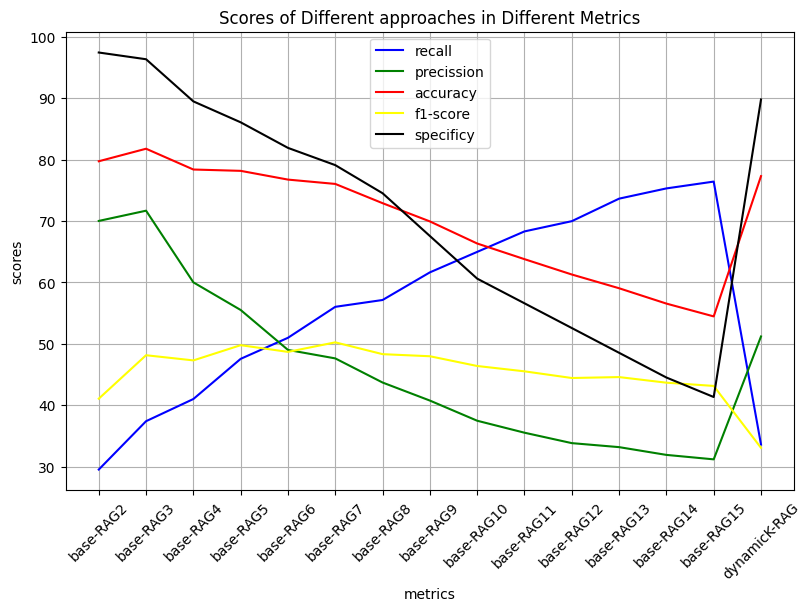

In [32]:
import matplotlib.pyplot as plt


scores = {
    'recall':plot_r,
    'precission': plot_p,
    'accuracy': plot_a,
    'f1-score': plot_f,
    'specificy':plot_s
}

metric_colors = {
    'recall': 'blue',
    'precission': 'green',
    'accuracy': 'red',
    'f1-score': 'yellow',
    'specificy':'black'
}

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
for metric, marks in scores.items():
    ax.plot(file_names, marks, label=metric, color=metric_colors[metric])

ax.set_xlabel('metrics')  # Use set_xlabel instead of xlabel
ax.set_ylabel('scores')   # Use set_ylabel instead of ylabel
ax.set_title('Scores of Different approaches in Different Metrics')  # Use set_title instead of title
ax.legend()  # You need to provide labels to the plot before calling legend
ax.grid(True)
ax.tick_params(axis='x', rotation=45)  # Use tick_params to rotate x-axis labels
fig.show()  # Use plt.show() instead of ax.show()

In [39]:
plot_a

[79.71437033433936,
 81.75378757963897,
 78.37005985844993,
 78.1529988039276,
 76.72873054219802,
 76.02357424958043,
 72.88984652839142,
 69.92046548470697,
 66.3251732578358,
 63.776261121462355,
 61.27846344796809,
 59.04009262213598,
 56.5422949486417,
 54.456186275071715,
 77.29466434419993]

In [34]:
wandb.login()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: farhan_dhanani. Use `wandb login --relogin` to force relogin


True

In [35]:
run = wandb.init(
    project="RAG_APP",
    name="experiment_RAG_open_ai",
    config={
        "data_set" : "FeTaQA",
        "data_items": 10,
        "sim_metric": "cosine"
    },
    settings = {"init_timeout":600,}
)

for log_key in logs:
    log_table = wandb.Table(dataframe=logs[log_key])
    run.log({log_key[:-5] + ".logs" : log_table})


run.finish()

# BI-ENCODER

## Training

In [10]:
dataset_path = "./dataset/"
encoder_model_path = "./encoder_models/"

In [11]:
df = pd.read_csv(dataset_path+'bi-encoder dataset.csv')

In [12]:
dataset = load_dataset("DongfuTingle/FeTaQA")

In [47]:
questions = []
labels = []
table_ids = []
json_docs = []

for index, row in df.iterrows():
    table_id = row['Sample_Id']
    table_question = row['Question']
    table_row_contain_ans = row['Row Index']
    
    '''
      # Loading data-frame
    '''
    headers = dataset['train'][table_id]['table_array'][0]
    content = dataset['train'][table_id]['table_array'][1:]
    table = pd.DataFrame(content, columns=headers)

    '''
      # Renaming duplicate column names
    '''
    s = pd.Series(table.columns)
    table.columns = table.columns+((" "+s.groupby(s).cumcount().astype(str)).replace(' 0','').astype(str))

    for table_row_index, row in table.iterrows():
        json_doc = row.to_dict()
        label = 1 if table_row_index == table_row_contain_ans else 0
        table_ids.append(table_id)
        labels.append(label)
        questions.append(table_question)
        json_docs.append(json_doc)
        
fine_tune_dataset = pd.DataFrame({'table_id': table_ids, 'questions': questions, 'row':json_docs, 'labels':labels})
fine_tune_dataset.to_csv(dataset_path+'fine_tune_dataset_for_bi_encoder.csv', index=False)

In [13]:
class FetaQADataset(torch.utils.data.Dataset):
    def __init__(self, datapath, nrows=None):
        if nrows:
            self.data = pd.read_csv(datapath, sep=",", nrows=nrows)
        else:
            self.data = pd.read_csv(datapath, sep=",")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data.iloc[idx]['questions'], self.data.iloc[idx]['row'], self.data.iloc[idx]['labels']

fetaQAdataset = FetaQADataset(dataset_path+'fine_tune_dataset_for_bi_encoder.csv')

In [14]:
class ContrastiveLoss(torch.nn.Module):
    def __init__(self, margin=0.5):
        """
        Contrastive Loss using Cosine Similarity.

        Args:
            margin (float): Margin value for negative samples. Default is 0.5.
        """
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        """
        Compute the contrastive loss.

        Args:
            output1: Embedding of the first sample.
            output2: Embedding of the second sample.
            label: Binary label (1 for similar, 0 for dissimilar).
        
        Returns:
            loss_contrastive: Calculated contrastive loss.
        """
        # Compute cosine similarity
        cosine_similarity = torch.nn.functional.cosine_similarity(output1, output2, dim=-1)

        print(cosine_similarity)
        
        # Convert cosine similarity to distance-like score (1 - similarity)
        cosine_distance = 1 - cosine_similarity

        
        # Positive pair loss (label = 1 means similar)
        pos_loss = (label) * torch.pow(cosine_distance, 2)
        
        # Negative pair loss (label = 1 means dissimilar)
        neg_loss = (1 - label) * torch.pow(torch.clamp(self.margin - cosine_distance, min=0.0), 2)
        
        # Final loss
        loss_contrastive = torch.mean(pos_loss + neg_loss)
        return loss_contrastive

In [15]:
class Encoder(torch.nn.Module):
    def __init__(self, vocab_size, embed_dim, output_embed_dim):
        super().__init__()
        self.embedding_layer = torch.nn.Embedding(vocab_size, embed_dim)
        self.encoder = torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(embed_dim, nhead=8, batch_first=True),
            num_layers=3,
            norm=torch.nn.LayerNorm([embed_dim]),
            enable_nested_tensor=False
        )
        self.projection = torch.nn.Linear(embed_dim, output_embed_dim)
    
    def forward(self, tokenizer_output):
        x = self.embedding_layer(tokenizer_output['input_ids'])
        x = self.encoder(x, src_key_padding_mask=tokenizer_output['attention_mask'].logical_not())
        cls_embed = x[:,0,:]
        return self.projection(cls_embed)

In [16]:
class BertEncoder(torch.nn.Module):
    def __init__(self, pretrained_model_name, output_embed_dim):
        super().__init__()
        # Load the pretrained BERT base model
        self.bert = BertModel.from_pretrained(pretrained_model_name)
        
        # Linear layer to project the last hidden state to the desired output dimension
        bert_hidden_size = self.bert.config.hidden_size
        self.projection = torch.nn.Linear(bert_hidden_size, output_embed_dim)
    
    def forward(self, tokenizer_output):
        """
        Args:
            tokenizer_output (dict): A dictionary containing:
                - input_ids: Tensor of token IDs [batch_size, seq_len]
                - attention_mask: Tensor indicating non-padding tokens [batch_size, seq_len]

        Returns:
            torch.Tensor: Projected embeddings of all tokens [batch_size, seq_len, output_embed_dim]
        """
        # Pass input through BERT
        outputs = self.bert(
            input_ids=tokenizer_output['input_ids'],
            attention_mask=tokenizer_output['attention_mask']
        )
        
        # Extract the last hidden state
        last_hidden_state = outputs.last_hidden_state  # [batch_size, seq_len, hidden_size]
        cls_embed = last_hidden_state[:,0,:]
        # Apply the projection layer to each token embedding
        projected_hidden_state = self.projection(cls_embed)  # [batch_size, output_embed_dim]
        
        return projected_hidden_state

In [55]:
def train(dataset, num_epochs=10):
    doc_encoder_model = "bert-base-uncased"
    doc_embed_size = 1024
    question_embed_size = 512
    output_embed_size = 1024
    max_seq_len = 128
    batch_size = 4

    n_iters = len(dataset) // batch_size + 1
    
    # Define the question/answer encoders
    tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
    question_encoder = Encoder(tokenizer.vocab_size, question_embed_size, output_embed_size)
    answer_encoder = BertEncoder(doc_encoder_model, output_embed_size)

    # Define the dataloader, optimizer, and loss function
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)    
    optimizer = torch.optim.Adam(list(question_encoder.parameters()) + list(answer_encoder.parameters()), lr=1e-5)
    contrastive_loss_fn = ContrastiveLoss(margin=0.5)

    for epoch in tqdm(range(num_epochs)):
        running_loss = []
        for idx, data_batch in tqdm(enumerate(dataloader)):

            # Tokenize the question/answer pairs
            question, answer, labels = data_batch
            question_tok = tokenizer(question, padding=True, truncation=True, return_tensors='pt', max_length=max_seq_len)
            answer_tok = tokenizer(answer, padding=True, truncation=True, return_tensors='pt', max_length=max_seq_len)
            
            if idx == 0 and epoch == 0:
                print(question_tok['input_ids'].shape, answer_tok['input_ids'].shape)
            
            # Compute the embeddings
            question_embed = question_encoder(question_tok)
            answer_embed = answer_encoder(answer_tok)
            
            if idx == 0 and epoch == 0:
                print(question_embed.shape, answer_embed.shape)
 
            # Compute contrastive loss
            labels = labels.float()  # Ensure labels are float for compatibility
            loss = contrastive_loss_fn(question_embed, answer_embed, labels)
            running_loss += [loss.item()]
            
            if idx == n_iters - 1:
                print(f"Epoch {epoch}, loss = ", np.mean(running_loss))
    
            # Perform optimization
            optimizer.zero_grad()    # Reset gradients
            loss.backward()          # Backpropagate
            optimizer.step()         # Update weights

    return question_encoder, answer_encoder

In [57]:
qe, ae = train(fetaQAdataset, num_epochs=5)
torch.save(qe.state_dict(), encoder_model_path+"question_encoder.pth")
torch.save(ae.state_dict(), encoder_model_path+"answer_encoder.pth")

  0%|                                                     | 0/5 [00:00<?, ?it/s]
0it [00:00, ?it/s]

torch.Size([4, 19]) torch.Size([4, 128])
torch.Size([4, 1024]) torch.Size([4, 1024])
tensor([-0.0421, -0.0344, -0.0464, -0.0019], grad_fn=<SumBackward1>)



1it [00:04,  4.72s/it]

tensor([-0.0306, -0.0273, -0.0232, -0.0132], grad_fn=<SumBackward1>)



2it [00:06,  2.81s/it]

...


468it [15:00,  1.76s/it]

tensor([0.4898, 0.4980, 0.4954, 0.5376], grad_fn=<SumBackward1>)



469it [15:02,  1.76s/it]

tensor([0.5055, 0.4875, 0.5141, 0.4904], grad_fn=<SumBackward1>)



470it [15:04,  1.92s/it]
100%|██████████████████████████████████████████| 5/5 [1:18:52<00:00, 946.46s/it]


## RELOADING TRAINED MODELS

In [17]:
question_embed_size = 512
output_embed_size = 1024
doc_encoder_model = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Reinitialize the encoders
loaded_question_encoder = Encoder(tokenizer.vocab_size, question_embed_size, output_embed_size)
loaded_answer_encoder = BertEncoder(doc_encoder_model, output_embed_size)

# Load the state dictionaries
loaded_question_encoder.load_state_dict(torch.load(encoder_model_path+"question_encoder.pth"))
loaded_answer_encoder.load_state_dict(torch.load(encoder_model_path+"answer_encoder.pth"))

# Ensure the models are in evaluation mode
loaded_question_encoder.eval()
loaded_answer_encoder.eval()

BertEncoder(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

## SETUP VECTOR STORE PINECONE

In [32]:
pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])

index_name = "fine-tuned-biencoder-rag"
vc_dimension=3072 if using_open_ai else 1024

if not pc.has_index(index_name):
  pc.create_index(
        name=index_name,
        dimension=vc_dimension,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )
  
  while not pc.describe_index(index_name).status["ready"]:
        time.sleep(1)

pinecone_index = pc.Index(index_name)

# Generating Embeddings

In [33]:
from typing import List
class CustomTorchEmbedder:
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer
        self.model.eval()

    def __call__(self, texts: List[str]) -> List[List[float]]:
        embeddings = []
        for text in texts:
            with torch.no_grad():
                # Convert text to tensor input (you may need to tokenize)
                inputs = self.preprocess_text(text)
                output = self.model(inputs)
                embeddings.append(output.squeeze().numpy().tolist())
        return embeddings

    def preprocess_text(self, text: str) -> torch.Tensor:
        # Add your tokenizer or preprocessing here
        doc_tok = self.tokenizer(text, padding=True, truncation=True, return_tensors='pt', max_length=128)
        return doc_tok

In [34]:
from langchain.embeddings.base import Embeddings
class LangChainTorchEmbedder(Embeddings):
    def __init__(self, pytorch_embedder):
        self.embedder = pytorch_embedder

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        return self.embedder(texts)

    def embed_query(self, text: str) -> List[float]:
        return self.embedder([text])[0]

In [35]:
doc = ["hello"]
doc_encoder = CustomTorchEmbedder(loaded_answer_encoder, tokenizer)
lang_chain_doc_encoder = LangChainTorchEmbedder(doc_encoder)
lang_chain_doc_encoder.embed_documents(doc)

[[0.13487409055233002,
  0.03434179723262787,
  -0.1967054009437561,
  0.048013001680374146,
  0.18606281280517578,
  0.6748040914535522,
  0.6443514227867126,
  0.16913366317749023,
  -0.7259588241577148,
  -0.7007978558540344,
  -0.27842485904693604,
  -0.13642291724681854,
  -0.2640650272369385,
  -0.7603405714035034,
  -0.09680483490228653,
  0.044090256094932556,
  0.4613434970378876,
  -0.3481292724609375,
  0.06292572617530823,
  0.06139778345823288,
  0.10676650702953339,
  -0.10381090641021729,
  -0.3760226368904114,
  0.26781636476516724,
  0.24251306056976318,
  -0.10010375082492828,
  -0.6552515029907227,
  -0.5675540566444397,
  -0.2300262451171875,
  0.28049716353416443,
  -0.08008946478366852,
  -0.13592466711997986,
  0.10541996359825134,
  0.3957133889198303,
  0.21549828350543976,
  0.0010639745742082596,
  -0.9150497913360596,
  -0.08679654449224472,
  -0.5790320634841919,
  0.6587057709693909,
  0.0581461563706398,
  0.45513519644737244,
  0.6011109948158264,
  -0.4

In [36]:
pinecone_index.describe_index_stats()

{'dimension': 1024,
 'index_fullness': 0.0,
 'namespaces': {},
 'total_vector_count': 0}

In [38]:
existing_namespaces = pinecone_index.describe_index_stats()['namespaces']

In [39]:
existing_namespaces

{}

In [40]:
vector_store = PineconeVectorStore(
    index = pinecone_index,
    embedding=lang_chain_doc_encoder,
    pinecone_api_key=os.environ["PINECONE_API_KEY"]
)

In [41]:
datasetFileName = "dataset/TQA.json"
processed_tables = _preprocess_tables(datasetFileName)

In [42]:
for namespace in tqdm(processed_tables):
    try:
        if namespace not in existing_namespaces:
            documents = processed_tables[namespace]
            vector_store.add_documents(documents=documents, async_req=False, namespace=namespace)
        else:
            print("The namespace already exists: " + namespace)
    except Exception as e:
        print("Error occurred while upserting for namespace: "+ namespace)
        print(e)
    
print("Documents added successfully.")

100%|███████████████████████████████████████████| 10/10 [00:31<00:00,  3.13s/it]

Documents added successfully.


# Querying Pine-Cone Index

Retrieving relevant records from the Pine-Cone Index for the sampled queries and storing the results back in Google-Drive.

In [43]:
def retriever(query, namespace, vs, k=2):
    return vs.similarity_search(query, namespace=namespace, k=k)

def retriever_with_scores(query, namespace, vs, k=2):
    return vs.similarity_search_with_score(query, namespace=namespace, k=k)

In [44]:
results_path = "results/"
retreivedResultsBiEncoderDynamicK = "biEncoder-RAG.json"
tqa_dataset = "./dataset/TQA.json"

In [45]:
def trim_to_max_k(array, max_k):
    # Sort the array in descending order
    sorted_array = sorted(array, reverse=True)
    # Keep only the first `max_k` elements
    trimmed_array = sorted_array[:max_k]
    return trimmed_array

In [46]:
query_encoder = CustomTorchEmbedder(loaded_question_encoder, tokenizer)
lang_chain_query_encoder = LangChainTorchEmbedder(query_encoder)

In [47]:
vs = PineconeVectorStore(
    index = pinecone_index,
    embedding=lang_chain_query_encoder,
    pinecone_api_key=os.environ["PINECONE_API_KEY"]
)

In [49]:
with open(tqa_dataset, 'r', encoding='utf8') as infile:
    processedDataSet = json.load(infile)

In [63]:
init_k = 2
max_k_for_rag = 7
totalRecordsToSample = 10
dataset = load_dataset("DongfuTingle/FeTaQA")
responses = []
for idx in tqdm(range(totalRecordsToSample)):
    query = dataset['train'][idx]['question']
    namespace = keep_ascii_printable(
        dataset['train'][idx]['table_page_title']  + 
        " " + 
        dataset['train'][idx]['table_section_title']
    )
    
    resultsDocs = retriever_with_scores(query, namespace, vs, len(processedDataSet[idx][namespace]))
    retrievedResults = []
    scores = []
    for resultDoc, score in resultsDocs:
        scores.append(score)
        retrievedResults.append(json.loads(resultDoc.page_content))

    score_num = np.array(scores)
    data = score_num.reshape(-1, 1)

    if len(scores) < init_k:
        print("Not enough data for clustering.")
        continue

    # Silhouette method initialization
    max_k = len(scores)  # Maximum number of clusters
    k_values_for_silhouette = []
    silhouette_scores = []

    # Calculate silhouette scores for different values of k
    for k in range(init_k, max_k):
        kmeans = KMeans(n_clusters=k, random_state=50)
        labels = kmeans.fit_predict(data)
        silhouette_avg = silhouette_score(data, labels)
        silhouette_scores.append(silhouette_avg)
        k_values_for_silhouette.append(k)

    # Determine the optimal number of clusters
    optimal_k = k_values_for_silhouette[np.argmax(silhouette_scores)]

    kmeans = KMeans(n_clusters=optimal_k, random_state=50)
    labels = kmeans.fit_predict(data)
    centroids = kmeans.cluster_centers_

    # Find the largest centroid
    largest_centroid_index = np.argmax(centroids[:, 0])
    largest_centroid_value = centroids[largest_centroid_index][0]

    # Filter relevant scores
    relevant_scores = score_num[labels == largest_centroid_index]
    relevant_scores = trim_to_max_k(relevant_scores, max_k_for_rag)
    optimal_k_for_rag = len(relevant_scores)
    print("Optimal K: "+ str(optimal_k_for_rag)+" for "+str(idx))
    
    final_response = []
    for resultDoc, score in resultsDocs:
        if score in relevant_scores:
            final_response.append(json.loads(resultDoc.page_content))
        
    retreivedResponse= {
        'namespace':namespace,
        'question': query,
        'K':optimal_k_for_rag,
        'retrievedResults': final_response
    }
    responses.append(retreivedResponse)

 10%|████▍                                       | 1/10 [00:01<00:13,  1.46s/it]

Optimal K: 1 for 0


 20%|████████▊                                   | 2/10 [00:02<00:08,  1.01s/it]

Optimal K: 7 for 1


 30%|█████████████▏                              | 3/10 [00:02<00:04,  1.43it/s]

...

Optimal K: 2 for 7


 90%|███████████████████████████████████████▌    | 9/10 [00:04<00:00,  2.41it/s]

Optimal K: 7 for 8


100%|███████████████████████████████████████████| 10/10 [00:04<00:00,  2.00it/s]

Optimal K: 7 for 9


In [64]:
with open(base_path+results_path+retreivedResultsBiEncoderDynamicK, "w", encoding='utf8') as outfile:
    outfile.write(json.dumps(responses, indent = 4, ensure_ascii=False))

# Evaluation

In [65]:
results_path = "results/"
totalRecordsToSample = 10
retreivedResultsFileName = "biEncoder-RAG"

In [70]:
import warnings
warnings.filterwarnings("ignore")

file_names = []
file_names.append(retreivedResultsFileName)

plot_r = []
plot_p = []
plot_a = []
plot_f = []
plot_s = []
logs = {}

for file in file_names:
    
  with open(base_path+results_path+file+".json", 'r', encoding='utf8') as infile:
        result = json.load(infile)

  avg_recall = 0
  avg_precission = 0
  avg_accuracy = 0
  avg_f1_score = 0
  avg_specificity = 0

  recalls = []
  precissions = []
  numerator_p = []
  numerator_r = []
  denominator_p = []
  denominator_r = []
  questions = []
  answers = []
  json_tables = []
  highlighted_cell_ids = []
  ground_truth_cells = []
  retrieved_ans = []
  namespaces = []
  value_of_k = []      

  for i in tqdm(range(totalRecordsToSample)):
    cell_ids = dataset['train'][i]['highlighted_cell_ids']
    headers = dataset['train'][i]['table_array'][0]
    content = dataset['train'][i]['table_array'][1:]
    record_sub =  keep_ascii_printable(
        dataset['train'][i]['table_page_title']  + 
        " " + 
        dataset['train'][i]['table_section_title']
    )
    highlighted_cell_ids.append(json.dumps(cell_ids))
    json_tables.append(json.dumps(dataset['train'][i]['table_array']))
    questions.append(dataset['train'][i]['question'])
    answers.append(dataset['train'][i]['answer'])
    retrieved_ans.append(json.dumps(result[i]['retrievedResults']))
    namespaces.append(result[i]['namespace'])
    value_of_k.append(result[i]['K'])
      
    g_cells = []
    for cell_id in dataset['train'][i]['highlighted_cell_ids']:
        g_cells.append(dataset['train'][i]['table_array'][cell_id[0]][cell_id[1]])
    ground_truth_cells.append(json.dumps(g_cells))
    table = pd.DataFrame(content, columns=headers)

    # Renaming duplicate column names
    s = pd.Series(table.columns)
    table.columns = table.columns + ((" " + s.groupby(s).cumcount().astype(str)).replace(' 0', '').astype(str))

    headers = list(table.columns)
    '''
      # Creating rows & cols chunks
    '''
    rowChunks = table.to_dict('records')
    colChunks = table.to_dict('list')
    allChunks_set = set()

    for row in rowChunks:
      #row['record'] = record_sub
      allChunks_set.add(json.dumps(row))

    for col in colChunks:
      colChunk = colChunks[col]
      allChunks_set.add(
          json.dumps(
              {
                  col:colChunk, 
                  #'record':record_sub
              }
          )
      )

    allChunks = [eval(x) for x in allChunks_set]
    total_table_chunks = len(allChunks)

    ground_truth_ans = []
    good_chunks_set = set()


    for cell_id in cell_ids:
      ans = {}
      ans_row = {}
      ans_col = {}
      rowIndex = cell_id[0]-1
      colIndex = cell_id[1]

      ans["label"] = table.iloc[rowIndex,colIndex]
      ans["row"] = table.to_dict('records')[cell_id[0]-1]
      #ans["row"]['record'] = record_sub
      ans["col"] =  { \
                      headers[cell_id[1]]:table.to_dict('list')[headers[cell_id[1]]], \
                      #'record':record_sub
                    }
      ground_truth_ans.append(ans)

      row = table.to_dict('records')[cell_id[0]-1]
      #row['record'] = record_sub

      good_chunks_set.add(json.dumps(row))

      col =  { \
          headers[cell_id[1]]:table.to_dict('list')[headers[cell_id[1]]], \
          #'record':record_sub
      }
      good_chunks_set.add(json.dumps(col))

    good_chunks_list = [eval(x) for x in good_chunks_set]

    bad_chunks = [x for x in allChunks if x not in good_chunks_list]

    if(len(good_chunks_list) + len(bad_chunks) > len(allChunks)):
      print("invalid value for good_chunk + bad_chunk:",i)
      raise ValueError("invalid value")
    

    TN = 0
    retrieved_chunk_list = []
    for record in result[i]['retrievedResults']:
        print(record)
        retrieved_chunk_list.append(record)

    TP_chunk = [x for x in good_chunks_list if x in retrieved_chunk_list]

    TP = len(TP_chunk)

    FN_chunk = [x for x in good_chunks_list if x not in retrieved_chunk_list]

    FN = len(FN_chunk)

    TN_chunk = [x for x in bad_chunks if x not in retrieved_chunk_list]

    TN = len(TN_chunk)

    FP_chunk = [x for x in bad_chunks if x in retrieved_chunk_list]

    FP = len(FP_chunk)

    denominator_for_precission = (TP+FP)
    denominator_for_recall = (TP+FN)
    denominator_for_specificity = (TN+FP)
    denominator_for_accuracy = (TP+FP+FN+TN)

    if(denominator_for_accuracy==0):
      print("invalid denominator for accuracy at index:",index)
      raise ValueError("invalid value")

    if denominator_for_precission == 0:
      precission = 0
    else:
      precission = (TP / denominator_for_precission) * 100

    if denominator_for_recall == 0:
      recall = 0
    else:
      recall = (TP / denominator_for_recall) * 100

    if denominator_for_specificity == 0:
      specificity = 0
    else:
      specificity = (TN / denominator_for_specificity) * 100

    accuracy = ((TP + TN) / denominator_for_accuracy) * 100
    if precission + recall > 0:
      f1_score = 2 * ((precission * recall) / (precission + recall))
    else:
      f1_score = 0
     

    if(denominator_for_accuracy != len(allChunks)):
      print("invalid denominator for accuracy:",i)
      raise ValueError("invalid value")

    if(precission>100):
      print("invalid value for precission:",i)
      raise ValueError("invalid value")


    if(recall>100):
      print("invalid value for recall:",i)
      raise ValueError("invalid value")

    if(accuracy>100):
      print("invalid value for accuracy:",i)
      raise ValueError("invalid value")

    if(f1_score>100):
      print("invalid value for f1_score:",i)
      raise ValueError("invalid value")

    if(specificity>100):
      print("invalid value for specificity:",index)
      raise ValueError("invalid value")


    avg_recall += recall
    avg_precission += precission
    avg_accuracy += accuracy
    avg_f1_score += f1_score
    avg_specificity += specificity

    precissions.append(precission)
    recalls.append(recall)
    numerator_p.append(TP)
    numerator_r.append(TP)
    denominator_p.append(denominator_for_precission)
    denominator_r.append(denominator_for_recall)

  avg_recall /= totalRecordsToSample
  avg_precission /= totalRecordsToSample
  avg_accuracy /= totalRecordsToSample
  avg_f1_score /= totalRecordsToSample
  avg_specificity/= totalRecordsToSample

  plot_r.append(avg_recall)
  plot_p.append(avg_precission)
  plot_a.append(avg_accuracy)
  plot_f.append(avg_f1_score)
  plot_s.append(avg_specificity)

  log_data = {
    'namespace' : namespaces,
    'table_JSON' : json_tables,
    'question' : questions,
    'answer' : answers,
    'value_of_k': value_of_k,
    'ground_truth_cell_ids' : highlighted_cell_ids,
    'ground_truth_cells' : ground_truth_cells,
    'retrieved_results' : retrieved_ans,
    'recall': recalls,
    'precission': precissions,
  }  
    
  logs[file]  =  pd.DataFrame(log_data)

 50%|██████████████████████                      | 5/10 [00:00<00:00, 48.01it/s]

{'Party': '-', 'Party 1': 'Republican', 'Candidate': 'James R. Thompson (incumbent)', 'Votes': '1,816,101', '%': '49.44', '±': '-'}
{'Finish': '1', 'Start': '4', 'No': '3', 'Name': 'United States Bobby Rahal', 'Qual': '213.550', 'Laps': '200', 'Status': '170.722 mph'}
{'Finish': '4', 'Start': '8', 'No': '5', 'Name': 'Colombia Roberto Guerrero', 'Qual': '211.576', 'Laps': '200', 'Status': '+10.558 seconds'}
{'Finish': '2', 'Start': '6', 'No': '7', 'Name': 'United States Kevin Cogan', 'Qual': '211.922', 'Laps': '200', 'Status': '+1.441 seconds'}
{'Finish': '3', 'Start': '1', 'No': '4', 'Name': 'United States Rick Mears (W)', 'Qual': '216.828', 'Laps': '200', 'Status': '+1.881 seconds'}
{'table_section_title': 'Race box score'}
{'Finish': '5', 'Start': '9', 'No': '30', 'Name': 'United States Al Unser, Jr.', 'Qual': '211.533', 'Laps': '199', 'Status': 'Flagged'}
{'Finish': '6', 'Start': '3', 'No': '18', 'Name': 'United States Michael Andretti', 'Qual': '214.522', 'Laps': '199', 'Status': '

100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 41.40it/s]

{'Club': 'Elbasani', 'Season': '2009–10', 'League': 'Albanian First Division', 'League 1': '13', 'League 2': '3', 'Cup': '0', 'Cup 1': '0', 'Europe': '—', 'Europe 1': '—', 'Total': '13', 'Total 1': '3'}
{'Club': 'Bylis Ballsh', 'Season': 'Total', 'League': 'Total', 'League 1': '51', 'League 2': '6', 'Cup': '6', 'Cup 1': '0', 'Europe': '—', 'Europe 1': '—', 'Total': '57', 'Total 1': '6'}
{'Club': 'Teuta Durrës', 'Season': 'Total', 'League': 'Total', 'League 1': '44', 'League 2': '4', 'Cup': '8', 'Cup 1': '0', 'Europe': '2', 'Europe 1': '0', 'Total': '54', 'Total 1': '4'}
{'Club': 'Elbasani', 'Season': 'Total', 'League': 'Total', 'League 1': '81', 'League 2': '7', 'Cup': '4', 'Cup 1': '0', 'Europe': '—', 'Europe 1': '—', 'Total': '81', 'Total 1': '7'}
{'Club': 'Teuta Durrës', 'Season': '2012–13', 'League': 'Albanian Superliga', 'League 1': '21', 'League 2': '1', 'Cup': '4', 'Cup 1': '0', 'Europe': '—', 'Europe 1': '—', 'Total': '25', 'Total 1': '1'}
{'Club': "Trepça'89", 'Season': '2018–

In [74]:
plot_p

[36.61904761904761]

In [75]:
plot_r

[26.952380952380953]

In [72]:
wandb.login()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
wandb: Currently logged in as: farhan_dhanani. Use `wandb login --relogin` to force relogin


True

In [73]:
run = wandb.init(
    project="RAG_APP",
    name="experiment_RAG_biEncoder",
    config={
        "data_set" : "FeTaQA",
        "data_items": 10,
        "sim_metric": "cosine"
    },
    settings = {"init_timeout":600,}
)

for log_key in logs:
    log_table = wandb.Table(dataframe=logs[log_key])
    run.log({log_key[:-5] + ".logs" : log_table})


run.finish()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
